# Lab 10 — Angles and Similarity

## Dot products, cosine similarity, correlation, and high-dimensional direction

In Chapter 9 we measured **length** and **distance**. In this lab we measure **direction**.

The main idea is simple but powerful:

> Two vectors can be far apart as points but still point in the same direction.

This lab is longer than a quick practice. It is designed as a guided computational story. You will write Python functions, build visualizations, compare distance and cosine similarity, analyze text-like vectors, compare simple images, and explore high-dimensional angle behavior.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

def norm(u):
    return np.linalg.norm(u)

def cosine_similarity(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    denom = norm(u) * norm(v)
    if denom == 0:
        return np.nan
    return np.dot(u, v) / denom

def angle_degrees(u, v):
    c = cosine_similarity(u, v)
    c = np.clip(c, -1, 1)
    return np.degrees(np.arccos(c))

def plot_vectors(vectors, labels=None, title="Vectors from the origin"):
    if labels is None:
        labels = [f"v{i}" for i in range(len(vectors))]
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    max_abs = 1
    for vec, lab in zip(vectors, labels):
        vec = np.asarray(vec, dtype=float)
        ax.arrow(0, 0, vec[0], vec[1], head_width=0.08, length_includes_head=True)
        ax.text(vec[0]*1.05, vec[1]*1.05, lab, fontsize=12)
        max_abs = max(max_abs, abs(vec[0]), abs(vec[1]))
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(-1.2*max_abs, 1.2*max_abs)
    ax.set_ylim(-1.2*max_abs, 1.2*max_abs)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    plt.show()


## 1. Dot product as alignment

The dot product multiplies matching coordinates and adds them:

$$u \cdot v = \sum_i u_i v_i.$$

Positive terms mean coordinates reinforce each other. Negative terms mean they work against each other. A zero total means the positive and negative contributions cancel.

u dot same          =  15.00, cosine =  1.00, angle =  0.0 degrees
u dot opposite      = -15.00, cosine = -1.00, angle =  180.0 degrees
u dot perpendicular =  0.00, cosine =  0.00, angle =  90.0 degrees


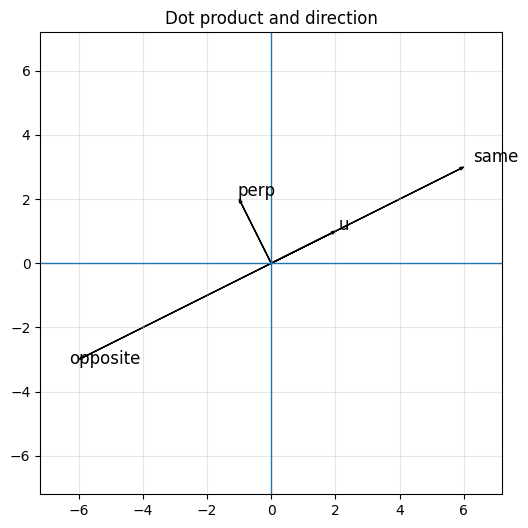

In [2]:
u = np.array([2, 1])
v_same = np.array([6, 3])
v_opposite = np.array([-6, -3])
v_perp = np.array([-1, 2])

for name, v in [("same", v_same), ("opposite", v_opposite), ("perpendicular", v_perp)]:
    print(f"u dot {name:13s} = {np.dot(u, v): .2f}, cosine = {cosine_similarity(u, v): .2f}, angle = {angle_degrees(u, v): .1f} degrees")

plot_vectors([u, v_same, v_opposite, v_perp], ["u", "same", "opposite", "perp"], "Dot product and direction")


### Student task 1
Create three vectors in $\mathbb{R}^2$:

1. one with positive dot product with `u`,
2. one with negative dot product with `u`,
3. one with zero dot product with `u`.

Then plot them.

u dot a = 5
u dot b = -5
u dot c = 0


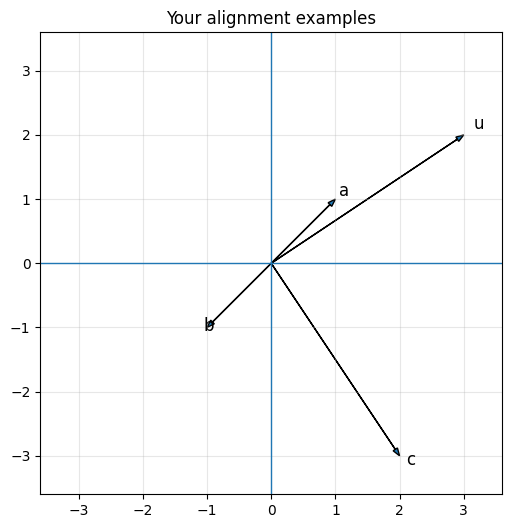

In [3]:
# TODO: Replace these vectors with your own examples.
u = np.array([3, 2])
a = np.array([1, 1])
b = np.array([-1, -1])
c = np.array([2, -3])

print("u dot a =", np.dot(u, a))
print("u dot b =", np.dot(u, b))
print("u dot c =", np.dot(u, c))
plot_vectors([u, a, b, c], ["u", "a", "b", "c"], "Your alignment examples")


## 2. Cosine similarity removes length

Cosine similarity is

$$\frac{u\cdot v}{\|u\|\|v\|}.$$

It compares direction rather than size.

In [4]:
alice = np.array([5, 5, 4, 1, 1], dtype=float)
bob = 2 * alice
carol = np.array([1, 1, 2, 5, 5], dtype=float)

ratings = pd.DataFrame({"Alice": alice, "Bob": bob, "Carol": carol},
                       index=["Movie 1", "Movie 2", "Movie 3", "Movie 4", "Movie 5"])
ratings


,Alice,Bob,Carol
Movie 1,5.0,10.0,1.0
Movie 2,5.0,10.0,1.0
Movie 3,4.0,8.0,2.0
Movie 4,1.0,2.0,5.0
Movie 5,1.0,2.0,5.0


In [5]:
names = ["Alice", "Bob", "Carol"]
X = np.column_stack([alice, bob, carol])
S = np.zeros((3,3))
D = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        S[i,j] = cosine_similarity(X[:,i], X[:,j])
        D[i,j] = norm(X[:,i] - X[:,j])

print("Cosine similarity matrix")
display(pd.DataFrame(S, index=names, columns=names))
print("Euclidean distance matrix")
display(pd.DataFrame(D, index=names, columns=names))


Cosine similarity matrix


,Alice,Bob,Carol
Alice,1.000000,1.000000,0.453743
Bob,1.000000,1.000000,0.453743
Carol,0.453743,0.453743,1.000000


Euclidean distance matrix


,Alice,Bob,Carol
Alice,0.000000,8.246211,8.246211
Bob,8.246211,0.000000,14.696938
Carol,8.246211,14.696938,0.000000


### Visualization: ratings as patterns

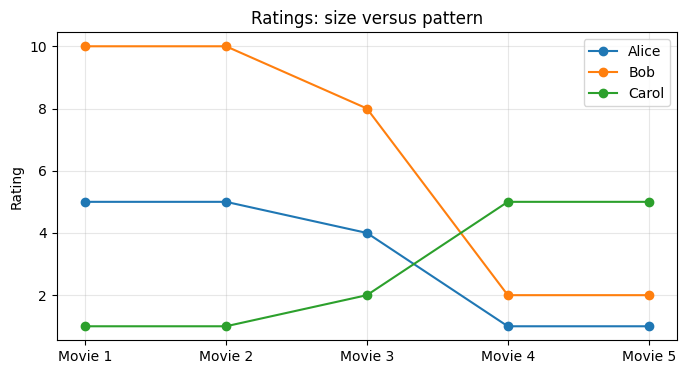

In [6]:
plt.figure(figsize=(8,4))
for name in names:
    plt.plot(ratings.index, ratings[name], marker='o', label=name)
plt.ylabel("Rating")
plt.title("Ratings: size versus pattern")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Distance and cosine can disagree

Two vectors can have high cosine similarity but large distance. They can also be close in distance but have noticeably different directions.

In [7]:
pairs = {
    "same direction, different size": (np.array([1,2]), np.array([10,20])),
    "nearby points, different direction": (np.array([1,0]), np.array([1,1])),
    "opposite directions": (np.array([2,1]), np.array([-2,-1])),
}

rows = []
for label, (p, q) in pairs.items():
    rows.append({
        "case": label,
        "distance": norm(p-q),
        "cosine": cosine_similarity(p,q),
        "angle_degrees": angle_degrees(p,q)
    })

pd.DataFrame(rows)


,case,distance,cosine,angle_degrees
0,"same direction, different size",20.124612,1.000000,8.537736e-07
1,"nearby points, different direction",1.000000,0.707107,4.500000e+01
2,opposite directions,4.472136,-1.000000,1.800000e+02


## 4. Centered cosine similarity equals correlation

Correlation is cosine similarity after subtracting each vector's average.

This matters when the baseline is not meaningful.

In [8]:
x = np.array([70, 80, 90], dtype=float)
y = np.array([170, 180, 190], dtype=float)
z = np.array([90, 80, 70], dtype=float)

def center(a):
    return a - np.mean(a)

def corr_by_cosine(a, b):
    return cosine_similarity(center(a), center(b))

print("raw cosine x,y:", cosine_similarity(x,y))
print("correlation x,y:", corr_by_cosine(x,y))
print("correlation x,z:", corr_by_cosine(x,z))
print("centered x:", center(x))
print("centered y:", center(y))
print("centered z:", center(z))


raw cosine x,y: 0.9984110664411946
correlation x,y: 0.9999999999999999
correlation x,z: -0.9999999999999999
centered x: [-10.   0.  10.]
centered y: [-10.   0.  10.]
centered z: [ 10.   0. -10.]


### Student task 2
Create two vectors with high raw cosine similarity but negative correlation. Explain why this can happen.

In [9]:
# TODO: Try changing these examples.
p = np.array([100, 101, 102], dtype=float)
q = np.array([102, 101, 100], dtype=float)

print("raw cosine:", cosine_similarity(p,q))
print("correlation:", corr_by_cosine(p,q))
print("centered p:", center(p))
print("centered q:", center(q))


raw cosine: 0.9998693024015685
correlation: -0.9999999999999998
centered p: [-1.  0.  1.]
centered q: [ 1.  0. -1.]


## 5. Text vectors and document similarity

We represent documents by word-count vectors. The coordinates are words. A document becomes a point or direction in a high-dimensional vocabulary space.

In [10]:
vocab = ["linear", "matrix", "vector", "recipe", "movie", "music", "actor", "song"]
docs = pd.DataFrame({
    "math_short": [3, 2, 2, 1, 0, 0, 0, 0],
    "math_long":  [12, 9, 8, 4, 0, 0, 0, 0],
    "movie":      [0, 0, 0, 0, 5, 0, 4, 0],
    "music":      [0, 0, 0, 0, 0, 6, 0, 5],
    "mixed":      [2, 1, 1, 0, 3, 0, 2, 0],
}, index=vocab)

docs


,math_short,math_long,movie,music,mixed
linear,3,12,0,0,2
matrix,2,9,0,0,1
vector,2,8,0,0,1
recipe,1,4,0,0,0
movie,0,0,5,0,3
music,0,0,0,6,0
actor,0,0,4,0,2
song,0,0,0,5,0


In [11]:
doc_names = docs.columns.tolist()
M = docs.to_numpy(dtype=float).T
sim = np.zeros((len(doc_names), len(doc_names)))
for i in range(len(doc_names)):
    for j in range(len(doc_names)):
        sim[i,j] = cosine_similarity(M[i], M[j])

sim_df = pd.DataFrame(sim, index=doc_names, columns=doc_names)
sim_df


,math_short,math_long,movie,music,mixed
math_short,1.000000,0.998724,0.000000,0.0,0.540738
math_long,0.998724,1.000000,0.000000,0.0,0.538589
movie,0.000000,0.000000,1.000000,0.0,0.824061
music,0.000000,0.000000,0.000000,1.0,0.000000
mixed,0.540738,0.538589,0.824061,0.0,1.000000


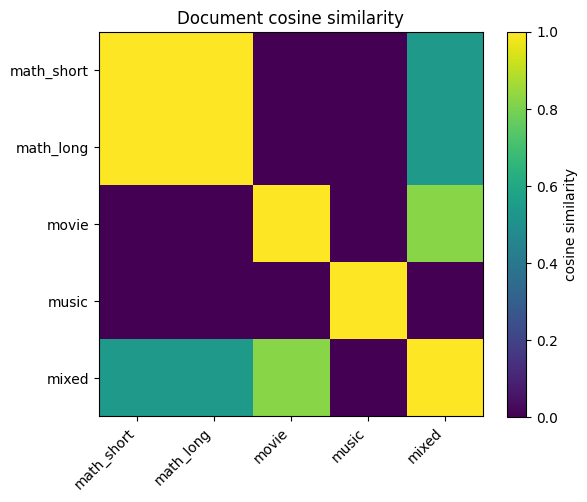

In [12]:
plt.figure(figsize=(6,5))
plt.imshow(sim_df, vmin=0, vmax=1)
plt.xticks(range(len(doc_names)), doc_names, rotation=45, ha='right')
plt.yticks(range(len(doc_names)), doc_names)
plt.colorbar(label="cosine similarity")
plt.title("Document cosine similarity")
plt.tight_layout()
plt.show()


## 6. Image similarity

Images can also be vectors. In this example we compare small binary images.

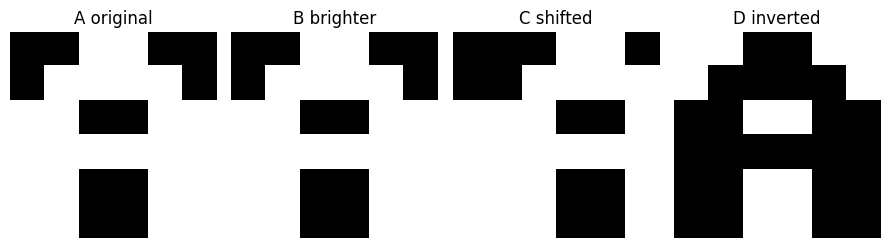

,image,distance from A,cosine with A
0,A original,0.000000,1.000000
1,B brighter,4.898979,1.000000
2,C shifted,3.162278,0.791667
3,D inverted,6.000000,0.000000


In [13]:
A = np.array([
    [0,0,1,1,0,0],
    [0,1,1,1,1,0],
    [1,1,0,0,1,1],
    [1,1,1,1,1,1],
    [1,1,0,0,1,1],
    [1,1,0,0,1,1]
], dtype=float)

B = 2 * A
C = np.roll(A, 1, axis=1)
D = 1 - A
images = {"A original": A, "B brighter": B, "C shifted": C, "D inverted": D}

plt.figure(figsize=(9,2.5))
for k, (name, img) in enumerate(images.items(), start=1):
    plt.subplot(1,4,k)
    plt.imshow(img, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

rows = []
for name, img in images.items():
    rows.append({
        "image": name,
        "distance from A": norm(A.ravel() - img.ravel()),
        "cosine with A": cosine_similarity(A.ravel(), img.ravel())
    })
pd.DataFrame(rows)


### Student task 3
Create a new $6\times 6$ image. Compare it to image `A` using both distance and cosine similarity.

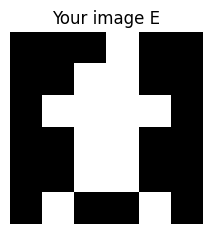

distance A,E: 4.358898943540674
cosine A,E: 0.5095246653650681


In [14]:
# TODO: Draw your own pattern by changing the zeros and ones.
E = np.array([
    [0,0,0,1,0,0],
    [0,0,1,1,0,0],
    [0,1,1,1,1,0],
    [0,0,1,1,0,0],
    [0,0,1,1,0,0],
    [0,1,0,0,1,0]
], dtype=float)

plt.figure(figsize=(2.5,2.5))
plt.imshow(E, cmap='gray')
plt.title("Your image E")
plt.axis('off')
plt.show()

print("distance A,E:", norm(A.ravel() - E.ravel()))
print("cosine A,E:", cosine_similarity(A.ravel(), E.ravel()))


## 7. Dot products as machine-learning scores

Many models compute a score by

$$s = w \cdot x.$$

The weight vector $w$ defines what direction the model likes. The feature vector $x$ gets a high score when it aligns with $w$.

In [15]:
w = np.array([2, -1, 3], dtype=float)
examples = pd.DataFrame({
    "x1": [1, 3, 0, 2],
    "x2": [0, 2, 5, 1],
    "x3": [2, 1, 1, 4],
}, index=["A", "B", "C", "D"])
examples["score w dot x"] = examples.to_numpy() @ w
examples


,x1,x2,x3,score w dot x
A,1,0,2,8.0
B,3,2,1,7.0
C,0,5,1,-2.0
D,2,1,4,15.0


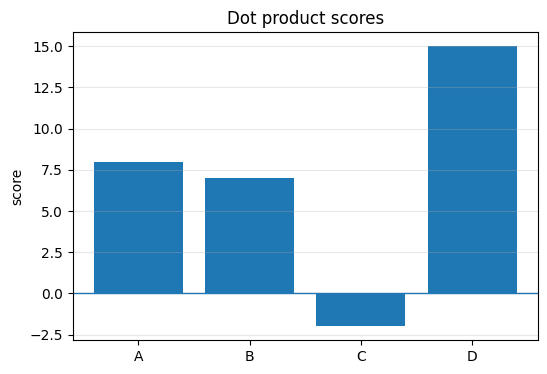

In [16]:
plt.figure(figsize=(6,4))
plt.bar(examples.index, examples["score w dot x"])
plt.axhline(0, linewidth=1)
plt.ylabel("score")
plt.title("Dot product scores")
plt.grid(True, axis='y', alpha=0.3)
plt.show()


## 8. High-dimensional random angles

In high dimensions, random vectors tend to be almost perpendicular. We will simulate this by drawing random Gaussian vectors.

In [17]:
dims = [2, 5, 10, 50, 100, 500, 1000]
rows = []
for d in dims:
    X = rng.normal(size=(5000, d))
    Y = rng.normal(size=(5000, d))
    cos = np.sum(X*Y, axis=1) / (np.linalg.norm(X, axis=1) * np.linalg.norm(Y, axis=1))
    rows.append({
        "dimension": d,
        "mean cosine": cos.mean(),
        "std cosine": cos.std(),
        "mean abs cosine": np.mean(np.abs(cos)),
        "95% quantile abs cosine": np.quantile(np.abs(cos), 0.95)
    })

hd = pd.DataFrame(rows)
hd


,dimension,mean cosine,std cosine,mean abs cosine,95% quantile abs cosine
0,2,-0.015615,0.709208,0.638421,0.997473
1,5,-0.000114,0.446093,0.374655,0.808204
2,10,-0.002796,0.310941,0.254357,0.594226
3,50,-0.002461,0.139278,0.111672,0.271231
4,100,0.000367,0.101674,0.081045,0.200352
5,500,0.000438,0.045037,0.036004,0.088520
6,1000,0.000534,0.031731,0.025340,0.061862


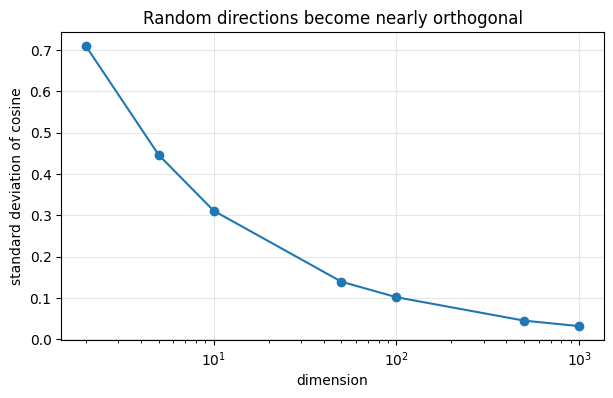

In [18]:
plt.figure(figsize=(7,4))
plt.plot(hd["dimension"], hd["std cosine"], marker='o')
plt.xscale('log')
plt.xlabel("dimension")
plt.ylabel("standard deviation of cosine")
plt.title("Random directions become nearly orthogonal")
plt.grid(True, alpha=0.3)
plt.show()


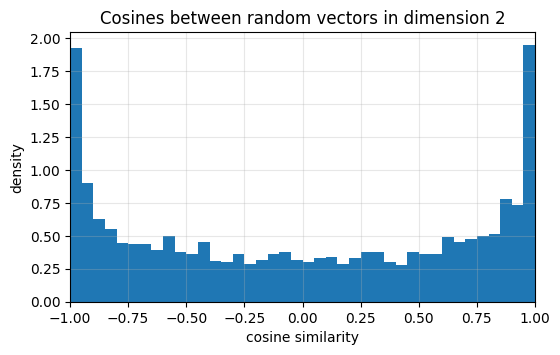

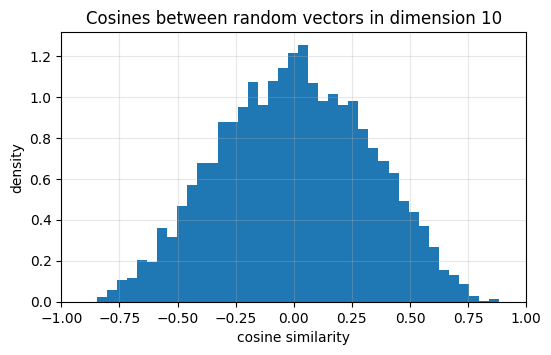

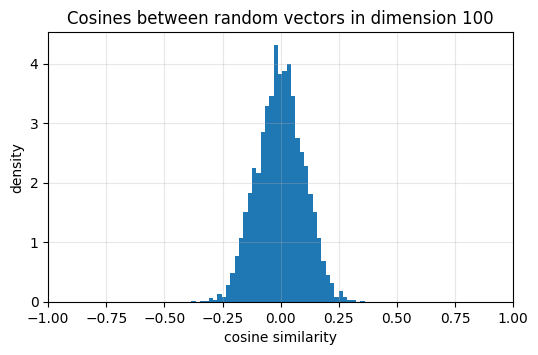

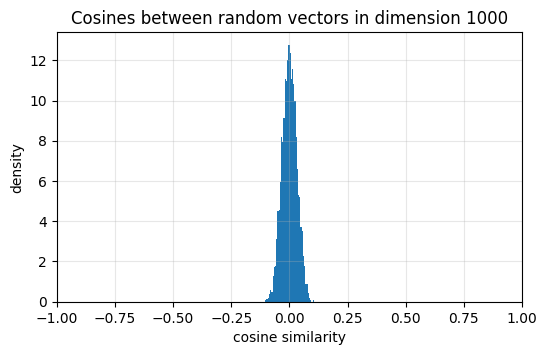

In [19]:
for d in [2, 10, 100, 1000]:
    X = rng.normal(size=(4000, d))
    Y = rng.normal(size=(4000, d))
    cos = np.sum(X*Y, axis=1) / (np.linalg.norm(X, axis=1) * np.linalg.norm(Y, axis=1))
    plt.figure(figsize=(6,3.5))
    plt.hist(cos, bins=40, density=True)
    plt.xlim(-1,1)
    plt.xlabel("cosine similarity")
    plt.ylabel("density")
    plt.title(f"Cosines between random vectors in dimension {d}")
    plt.grid(True, alpha=0.3)
    plt.show()


## 9. Cosine nearest neighbors

Search engines and recommendation systems often find nearest neighbors by cosine similarity rather than Euclidean distance.

In [20]:
# Build synthetic item vectors in a 6-dimensional taste space.
items = pd.DataFrame({
    "action_movie":  [5,4,0,0,1,0],
    "superhero":     [4,5,0,0,1,0],
    "romance":       [0,0,5,4,1,0],
    "classical":     [0,0,0,0,1,5],
    "symphony":      [0,0,0,0,1,4],
    "mixed_drama":   [1,1,3,3,2,0],
}, index=["action", "adventure", "romance", "drama", "general", "music"])

query = np.array([4,4,0,0,1,0], dtype=float)

scores = []
for item in items.columns:
    x = items[item].to_numpy(dtype=float)
    scores.append({
        "item": item,
        "cosine_to_query": cosine_similarity(query, x),
        "distance_to_query": norm(query - x)
    })

pd.DataFrame(scores).sort_values("cosine_to_query", ascending=False)


,item,cosine_to_query,distance_to_query
0,action_movie,0.993848,1.000000
1,superhero,0.993848,1.000000
5,mixed_drama,0.355335,6.082763
4,symphony,0.042220,6.928203
3,classical,0.034139,7.549834
2,romance,0.026861,8.544004


## 10. Final reflection

Write a short answer to each question:

1. What does the dot product measure geometrically?
2. Why does cosine similarity ignore overall scale?
3. When is distance better than cosine similarity?
4. When is cosine similarity better than distance?
5. Why is correlation a centered version of cosine similarity?
6. What surprised you about high-dimensional angles?
